----

In [1]:
#Importar librerias que usare
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from math import factorial
from scipy import stats as st

In [6]:
#Cargar los archivos
games=pd.read_csv('./datasets/games.csv')

In [4]:
#corroborar informacion del DF
print(games.info())
print(games.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29

In [ ]:
#remplazo de los nombres de columnas
games.columns = games.columns.str.lower().str.replace(' ', '_')

In [ ]:
#Convierte los datos en los tipos necesarios.
games['user_score'] = games['user_score'].replace('tbd', np.nan)
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')
games['year_of_release'] = games['year_of_release'].astype('Int64')

In [ ]:
#Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.
ventas_por_ano = (
    games.groupby(['platform', 'year_of_release'])[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']]
    .sum()
    .reset_index()
)

ventas_por_ano['total_sales'] = ventas_por_ano[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

In [ ]:
top_platforms = (
    ventas_por_ano.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(10) 
    .index
)
games_per_year = games['year_of_release'].value_counts().sort_index()
print(top_platforms)
print(games_per_year)

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS'], dtype='object', name='platform')
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64


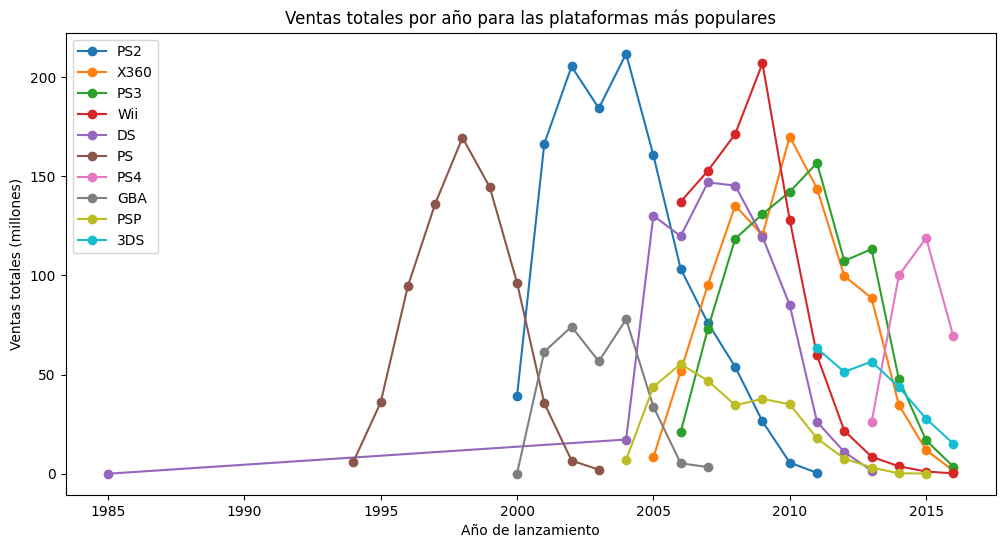

In [ ]:
ventas_top = ventas_por_ano[ventas_por_ano['platform'].isin(top_platforms)]
plt.figure(figsize=(12,6))
for plataforma in top_platforms:
    datos = ventas_top[ventas_top['platform'] == plataforma]
    plt.plot(datos['year_of_release'], datos['total_sales'], marker='o', label=plataforma)

plt.title('Ventas totales por año para las plataformas más populares')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales (millones)')
plt.legend()
plt.show()

In [ ]:
ultima_venta = (
    ventas_por_ano.groupby('platform')['year_of_release']
    .max()
    .reset_index()
    .rename(columns={'year_of_release': 'ultimo_año_ventas'})
)

In [ ]:
primera_venta = (
    ventas_por_ano.groupby('platform')['year_of_release']
    .min()
    .reset_index()
    .rename(columns={'year_of_release': 'primer_año_ventas'})
)

In [ ]:
vida_plataforma = primera_venta.merge(ultima_venta, on='platform')
vida_plataforma['duracion'] = vida_plataforma['ultimo_año_ventas'] - vida_plataforma['primer_año_ventas']

In [ ]:
vida_media = vida_plataforma['duracion'].mean()
print(f"En promedio, una plataforma tiene actividad durante {vida_media:.1f} años.")

En promedio, una plataforma tiene actividad durante 7.6 años.


In [ ]:
print(top_platforms)

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS'], dtype='object', name='platform')


In [ ]:
lanzamiento_plataforma = (
    games.groupby('platform')['year_of_release']
    .min()
    .reset_index()
    .rename(columns={'year_of_release': 'Año_Lanzamiento'})
)

print(lanzamiento_plataforma.sort_values('Año_Lanzamiento'))

   platform  Año_Lanzamiento
0      2600             1980
11      NES             1983
4        DS             1985
13       PC             1985
5        GB             1988
23     SNES             1990
8       GEN             1990
9        GG             1992
22      SCD             1993
12       NG             1993
21      SAT             1994
15       PS             1994
1       3DO             1994
24     TG16             1995
14     PCFX             1996
10      N64             1996
3        DC             1998
25       WS             1999
6       GBA             2000
29       XB             2000
16      PS2             2000
7        GC             2001
19      PSP             2004
28     X360             2005
17      PS3             2006
26      Wii             2006
2       3DS             2011
20      PSV             2011
27     WiiU             2012
18      PS4             2013
30     XOne             2013


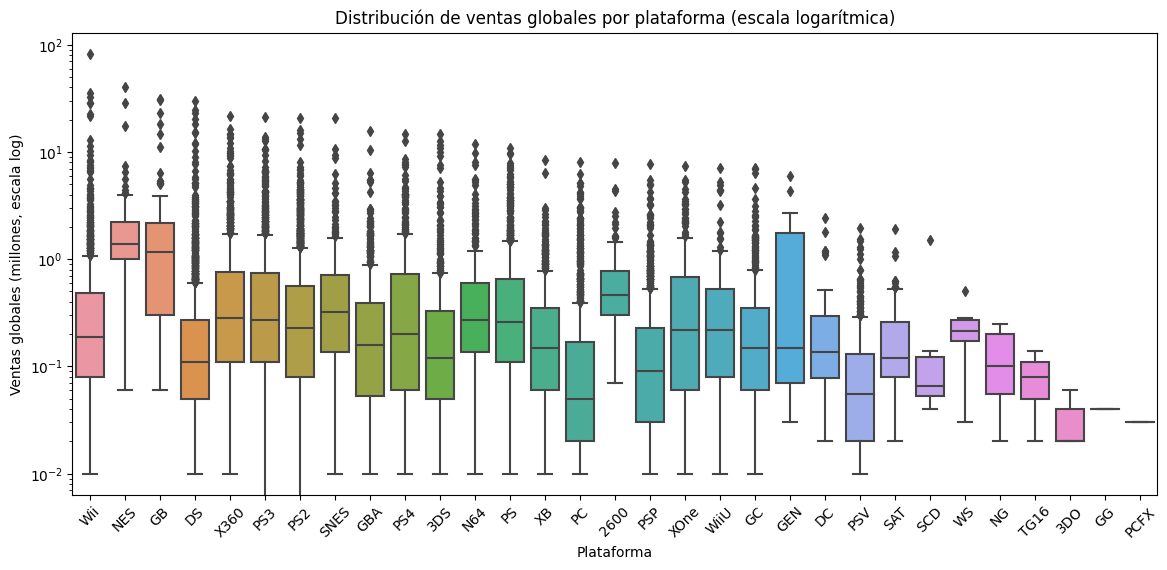

In [ ]:
games['global_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

plt.figure(figsize=(14, 6))
sns.boxplot(x='platform', y='global_sales', data=games)

plt.yscale('log')  # ← Escala logarítmica
plt.title('Distribución de ventas globales por plataforma (escala logarítmica)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales (millones, escala log)')
plt.xticks(rotation=45)
plt.show()

#con el anteirior diagrama podemos observar que si hay significancia en llas ventas de los videojuegos dependiendo de las plataformas, sin contar que tambien no debemos solo guiarnos de esto, por que tambien teniendo en cuenta el ano promedio de vida y de popularidad de algunas consolas, quizas no den una significancia real para el estudio.

In [ ]:
#para el siguiente paso el cual es hacer la correlacion entre el score o resenas y como afectan las ventas, escogere la plataforma del wii como eleccion y gusto personal.
plataforma = 'Wii'
games_plat = games[games['platform'] == plataforma].copy()

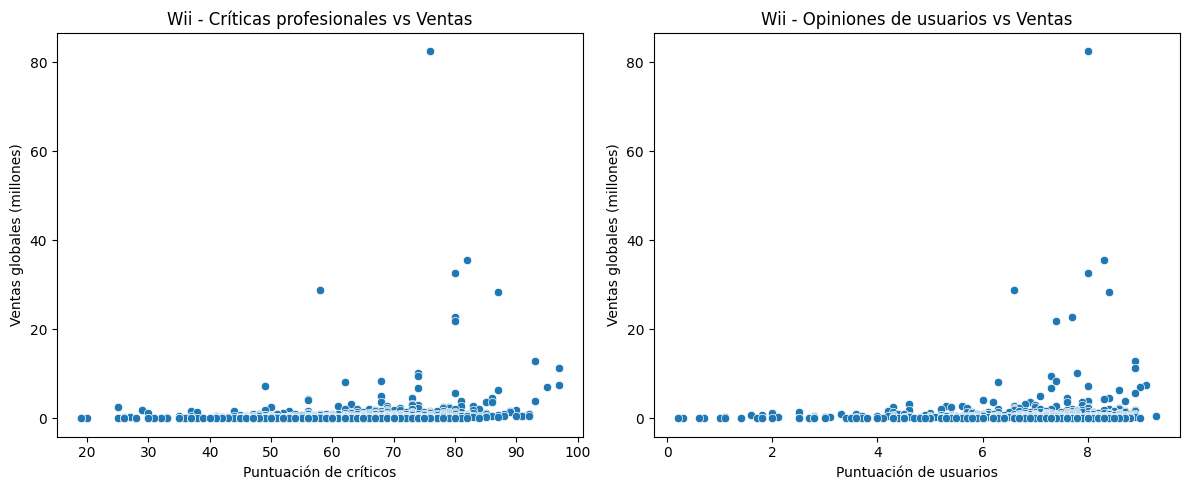

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='critic_score', y='global_sales', data=games_plat)
plt.title(f'{plataforma} - Críticas profesionales vs Ventas')
plt.xlabel('Puntuación de críticos')
plt.ylabel('Ventas globales (millones)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='user_score', y='global_sales', data=games_plat)
plt.title(f'{plataforma} - Opiniones de usuarios vs Ventas')
plt.xlabel('Puntuación de usuarios')
plt.ylabel('Ventas globales (millones)')

plt.tight_layout()
plt.show()

In [ ]:
corr_criticos = games_plat['critic_score'].corr(games_plat['global_sales'])
corr_usuarios = games_plat['user_score'].corr(games_plat['global_sales'])

print(f"Correlación Críticos-Ventas: {corr_criticos:.3f}")
print(f"Correlación Usuarios-Ventas: {corr_usuarios:.3f}")

Correlación Críticos-Ventas: 0.178
Correlación Usuarios-Ventas: 0.112


#en conclusion al obtener un valor de correlacion menores a 0.2 nos indica que no hay una relacion clara u existente entre las criticas de los usuarios o de los criticos con referencia a las ventas.

In [ ]:
juegos_multi = games.groupby('name')['platform'].nunique().reset_index()
juegos_multi = juegos_multi[juegos_multi['platform'] > 1]

print(f"Juegos con múltiples plataformas: {len(juegos_multi)}")

Juegos con múltiples plataformas: 2805


In [ ]:
games_multi = games[games['name'].isin(juegos_multi['name'])]
pivot_ventas = games.pivot_table(
    index='name',
    columns='platform',
    values='global_sales',
    aggfunc='sum'
)
multi_platform_games = pivot_ventas.dropna(thresh=2)
multi_platform_games = pivot_ventas.dropna(thresh=2).copy()
multi_platform_games['total_sales'] = multi_platform_games.sum(axis=1)
multi_platform_games['total_sales'] = multi_platform_games.sum(axis=1)
top__games = multi_platform_games.sort_values(by='total_sales', ascending=False).head(10)
top__games = top__games.drop(columns='total_sales')

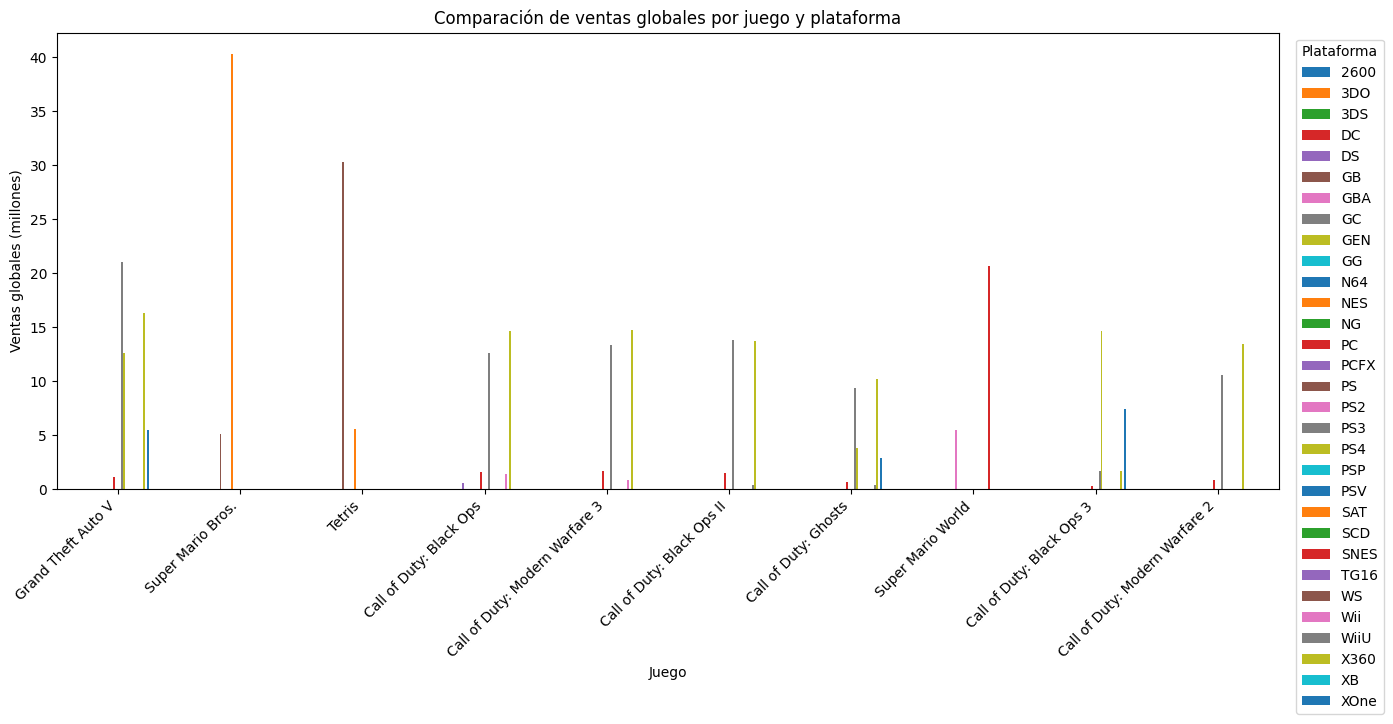

In [ ]:
top__games.plot(kind='bar', figsize=(14,7))
plt.title('Comparación de ventas globales por juego y plataforma')
plt.xlabel('Juego')
plt.ylabel('Ventas globales (millones)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper center')
plt.tight_layout()
plt.show()

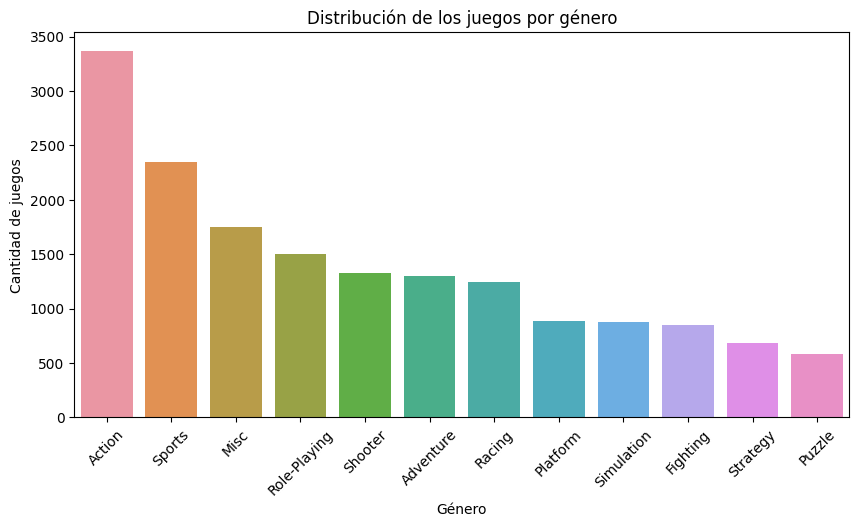

In [ ]:
juegos_por_genero = games['genre'].value_counts().reset_index()
juegos_por_genero.columns = ['genre', 'cantidad']

plt.figure(figsize=(10,5))
sns.barplot(x='genre', y='cantidad', data=juegos_por_genero)
plt.title('Distribución de los juegos por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de juegos')
plt.xticks(rotation=45)
plt.show()

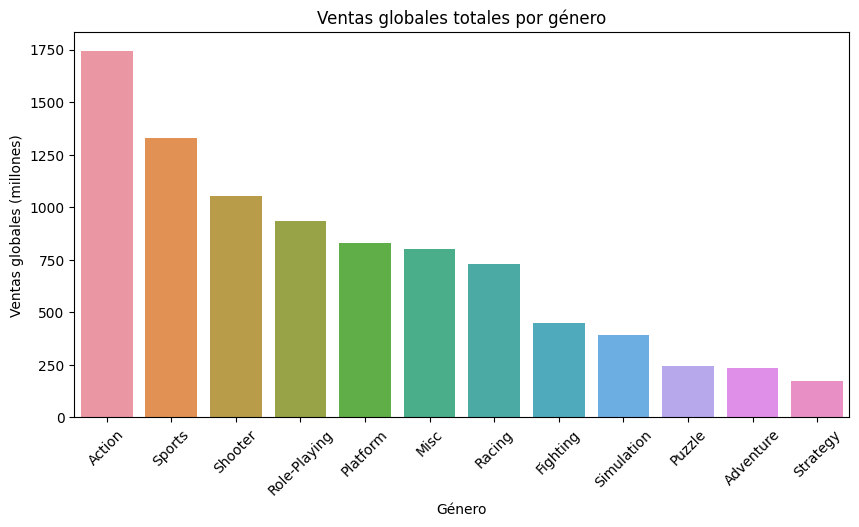

In [ ]:
ventas_por_genero = (
    games.groupby('genre')['global_sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(x='genre', y='global_sales', data=ventas_por_genero)
plt.title('Ventas globales totales por género')
plt.xlabel('Género')
plt.ylabel('Ventas globales (millones)')
plt.xticks(rotation=45)
plt.show()

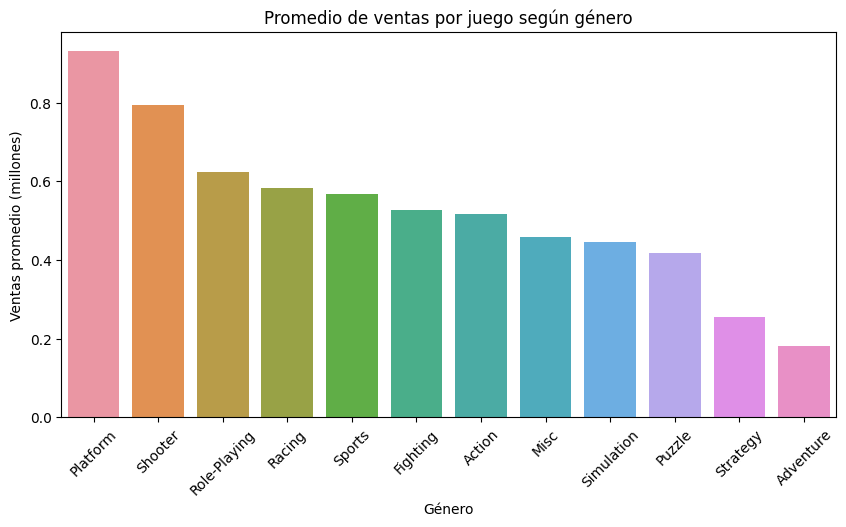

In [ ]:
promedio_por_genero = (
    games.groupby('genre')['global_sales']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(x='genre', y='global_sales', data=promedio_por_genero)
plt.title('Promedio de ventas por juego según género')
plt.xlabel('Género')
plt.ylabel('Ventas promedio (millones)')
plt.xticks(rotation=45)
plt.show()

#En conclusion, es importante no solo quedarnos con las ventas globales totales por genero, por que podriamos caer en un error el cual nos encasillaria a pensar que el genero mas rentable son los de accion pero sacando la tabla donde verificamos el promedio de ventas por juego segun el genero podemos llegar a una conclusion distinta en la cual podemos ver que los que mas generan ventas son los de genero de plataforma ya quetuvieron menos juegos pero sus ventas fueron mas rentables, es importante destacar que los juegos de accion tienen menos ventas en promedio por sus juegos, diciendonos, que bien podria no ser un genero rentable.

In [ ]:
#las 5 plataformas principales 
plataformas_region = (
    games.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales']]
    .sum()
    .sort_values('na_sales', ascending=False)
)

top5_NA = plataformas_region['na_sales'].sort_values(ascending=False).head(5)
top5_EU = plataformas_region['eu_sales'].sort_values(ascending=False).head(5)
top5_JP = plataformas_region['jp_sales'].sort_values(ascending=False).head(5)

print("Top 5 Plataformas en Norteamérica:\n", top5_NA)
print("\nTop 5 Plataformas en Europa:\n", top5_EU)
print("\nTop 5 Plataformas en Japón:\n", top5_JP)

Top 5 Plataformas en Norteamérica:
 platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 Plataformas en Europa:
 platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 Plataformas en Japón:
 platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


#En conclusion se observa que en Japón predominan las plataformas portátiles y de Sony; en cambio, en NA y EU las consolas de sobremesa (Xbox y PS) tienen más ventas.

In [ ]:
#los 5 generos principales
genero_region = (
    games.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']]
    .sum()
)

top5_NA_gen = genero_region['na_sales'].sort_values(ascending=False).head(5)
top5_EU_gen = genero_region['eu_sales'].sort_values(ascending=False).head(5)
top5_JP_gen = genero_region['jp_sales'].sort_values(ascending=False).head(5)

print("Top 5 géneros en NA:\n", top5_NA_gen)
print("\nTop 5 géneros en EU:\n", top5_EU_gen)
print("\nTop 5 géneros en JP:\n", top5_JP_gen)

Top 5 géneros en NA:
 genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Top 5 géneros en EU:
 genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Top 5 géneros en JP:
 genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


#En conclusion las preferencias de género varían mucho: los RPG dominan Japón bien puede ser por que los juegos mas fuertes nativos lansados fueron principalmente rpg, mientras que los juegos de disparos y deportes dominan Occidente.

In [ ]:
rating_region = (
    games.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']]
    .sum()
    .sort_values('na_sales', ascending=False)
)

print(rating_region)

        na_sales  eu_sales  jp_sales
rating                              
E        1292.99    710.25    198.11
T         759.75    427.03    151.40
M         748.48    483.97     64.24
E10+      353.32    188.52     40.20
K-A         2.56      0.27      1.46
EC          1.53      0.11      0.00
AO          1.26      0.61      0.00
RP          0.00      0.08      0.00


#nuevamente se puede concluir que las clasificaciones dominan de acuerdo a las regiones, como por ejemplo en jp la clasificacion dominante son las E y T mientras que en NA la que domina por mucho con las de clasificacion E, y en EU las dominantes con las M y T

In [ ]:
#para la primer prueba de hipotesis tenemos que nuestra H0=Las medias de calificación de usuarios en Xbox One y PC son iguales y tenemos nuestra H1=Las medias son diferentes

xbox_scores = games.loc[games['platform'] == 'XOne', 'user_score'].dropna()
pc_scores = games.loc[games['platform'] == 'PC', 'user_score'].dropna()


alpha = 0.05


t_stat, p_value = st.ttest_ind(xbox_scores, pc_scores, equal_var=False) 

print(f"T = {t_stat:.3f},  P = {p_value:.3f}")

if p_value < alpha:
    print("Rechazamos H₀: Las medias son significativamente diferentes.")
else:
    print("No se rechaza H₀: No hay evidencia de diferencia significativa.")

T = -4.653,  P = 0.000
Rechazamos H₀: Las medias son significativamente diferentes.


#con este resultado podemos decir que no hay diferencia estadísticamente significativa entre las calificaciones promedio de usuarios en Xbox One y PC.

In [ ]:
#para la siguiente prueba de hipotesis establecemos que H0=Las medias de calificación de usuarios en los géneros Action y Sports son iguales y para H1=Las medias de calificación de usuarios son diferentes.

action_scores = games.loc[games['genre'] == 'Action', 'user_score'].dropna()
sports_scores = games.loc[games['genre'] == 'Sports', 'user_score'].dropna()

t_stat2, p_value2 = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f"T = {t_stat2:.3f},  P = {p_value2:.3f}")

if p_value2 < alpha:
    print("Rechazamos H₀: Las calificaciones de Action y Sports son diferentes.")
else:
    print("No se rechaza H₀: No hay evidencia de diferencia significativa.")

T = 1.577,  P = 0.115
No se rechaza H₀: No hay evidencia de diferencia significativa.


#con los resultados obtenidos se puede concluir que sí existe una diferencia significativa entre las calificaciones de usuarios para los géneros Action y Sports.

#En los dos casos se tomo a alpha de 0.05, ya que es un valor comúnmente aceptado en este tipo de análisis.
#las hipotesis las formule de acuerdo a las instrucciones, tanto aqui como en mis otros estudios eh apreciado que la hipotesis nula es usualmente la que nos dan como problema o como inicial, ya posterior la hipotesis alternativa suele ser lo contrario o en algunos casos resultados distintos, pero en este caso los tome como los contrarios a la hipotesis nula.

Conclusion total: En este proyecto me entregaron un DF que contenia distintas columnas desde nombre ventas, score, etc. primero tuve que observar que tipo de datos contenia cada columna, de esta manera identificando que dos columnas contenian tipos de datos que no le correspondian y tuve que cambiarlo a lo correspondiente, lo cual suele suceder muy amenudo con los DF, posterior a ello observe que habian celdas con datos NAN o en algunos casos decian TBD se debia de cambiar a NAN parta poder cambiar el tipo de dato a lo correspondiente, en un inicio crei que seria prudente sustituir los datos NAN por la media pero esto genera un sesgo y puede crear resultados o graficas mal, por ello debido al elevado porcentaje de datos NAN se procedio a dejarlo de la misma manera, con esto se procedio para crear columnas de ventas totales de top de juegos de top de plataformas para poder generar graficos que nos ayuden a decidir a que tipo de plataformas y generos de videojuegos deberia de centrarse la compa;ia, en este trabajo obtivimos a simple vista que la opsion mas viable era a los juegos de genero de accion debido a que tienan ventas muy altas llegando a la suma de 1750 millones, sin embargo haciendo un analisis mas profundo se observo que las ventas promedio de cada juegos nos decia que los juegos de plataforma tenian mas ventas que los de accion (cerca de 1.5 veces mas)